# Bulk–surface recombination coupling in crystalline-silicon solar cells

Companion notebook for the manuscript *"Regime-Dependent Coupling of Bulk and Surface Recombination in Crystalline Silicon Solar Cells"*.

**Run all cells** (≈ 3 min on a standard CPU). Everything is seeded (seed = 42). The last code cell regenerates

| Output | Content |
|---|---|
| `outputs/data/si_cell_dataset.csv` | 23,814-device full-factorial dataset (21 τ × 21 S × 6 W × 9 N<sub>d</sub>) |
| `outputs/results.json` | every number quoted in the paper |
| `outputs/figures/fig1…fig7 (.png, .pdf)` | all figures |

**Physics model** (cm, s, A):

$$\frac{1}{\tau_{eff}}=\frac{1}{\tau_{bulk}}+\frac{2S}{W},\qquad J_0=\frac{q\,n_i^2\,W}{N_d\,\tau_{eff}}=\frac{q\,n_i^2}{N_d}\left(\frac{W}{\tau_{bulk}}+2S\right)\;\Rightarrow\; J_0=J_{0,bulk}+J_{0,surf}$$

$$J(V)=J_{ph}-J_0\left[e^{qV/kT}-1\right],\qquad V_{oc}=\frac{kT}{q}\ln\!\left(1+\frac{J_{ph}}{J_0}\right),\qquad \eta=\frac{P_{max}}{P_{in}}$$

The maximum power point is obtained exactly with the Lambert-W function. Fixed: T = 300 K, n<sub>i</sub> = 1.0×10¹⁰ cm⁻³, J<sub>ph</sub> = 40 mA cm⁻², P<sub>in</sub> = 100 mW cm⁻², ideality factor n = 1.

Requirements: `numpy, pandas, scipy, scikit-learn, matplotlib` (tested with numpy 2.4.4, pandas 3.0.2, scipy 1.17.1, scikit-learn 1.8.0, matplotlib 3.10.8).

## 0. Imports

In [1]:
import argparse, hashlib, itertools, json, os, platform, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.optimize import brentq
from scipy.special import lambertw
from scipy.stats import spearmanr
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


## 1. Constants and fixed model parameters

In [2]:
# ----------------------------------------------------------------------------
# 1. Constants and fixed model parameters
# ----------------------------------------------------------------------------
Q = 1.602176634e-19          # C
KB = 1.380649e-23            # J/K
T = 300.0                    # K
VT = KB * T / Q              # thermal voltage, V
NI = 1.0e10                  # cm^-3, intrinsic carrier density at 300 K (fixed)
JPH = 0.040                  # A/cm^2  (40 mA/cm^2) photogenerated current, held constant
PIN = 0.100                  # W/cm^2  (AM1.5G, 100 mW/cm^2)

# Parameter grid (full factorial)
TAU = np.logspace(-6, -2, 21)        # s     (1 us ... 10 ms, 5 points / decade)
SREC = np.logspace(0, 4, 21)         # cm/s  (1 ... 1e4, 5 points / decade)
W_UM = np.array([50., 100., 150., 200., 250., 300.])   # um
ND = np.logspace(15, 17, 9)          # cm^-3 (4 points / decade)
FEATURES = ["tau_bulk_s", "S_cm_s", "W_um", "Nd_cm3"]
FEATURE_SYMBOL = {"tau_bulk_s": r"$\tau_{bulk}$", "S_cm_s": r"$S$",
                  "W_um": r"$W$", "Nd_cm3": r"$N_d$"}

# Definitions used for classification
ETA_THR = 0.24               # "Gold Zone": eta >= 24 %
FS_LO, FS_HI = 0.2, 0.8      # regime thresholds on surface share of J0
VOC_AUGER = 0.76             # V, approx. intrinsic (Auger-limited) Voc of c-Si [Richter 2013]
C_AUGER_LOW = 1.0e-31        # cm^6/s, order of the low-injection Auger coefficients (Dziewior & Schmid 1977); sensitivity only
C_AUGER_HIGH = 1.66e-30      # cm^6/s, high-injection ambipolar Auger coefficient (Dziewior & Schmid 1977); strong-Auger stress test

# Reference slice used for maps / line cuts
W_REF_UM, ND_REF = 150.0, 1.0e16

SEED = 42
RF_KW = dict(n_estimators=500, random_state=SEED, n_jobs=-1)


## 2. Physics: device model and dataset builder

In [3]:
# ----------------------------------------------------------------------------
# 2. Physics
# ----------------------------------------------------------------------------
def model(tau_b, S, W_cm, Nd, c_aug=0.0):
    """Return dict of J0 components and device metrics (vectorised, exact)."""
    tau_b, S, W_cm, Nd = np.broadcast_arrays(*[np.asarray(a, float) for a in (tau_b, S, W_cm, Nd)])
    inv_tb = 1.0 / tau_b + c_aug * Nd ** 2                # optional intrinsic (Auger) cap
    inv_te = inv_tb + 2.0 * S / W_cm                      # Eq. (1)
    pref = Q * NI ** 2 / Nd
    j0b = pref * W_cm * inv_tb
    j0s = pref * 2.0 * S
    j0 = pref * W_cm * inv_te                             # Eq. (2)
    out = dict(tau_eff=1.0 / inv_te, J0_bulk=j0b, J0_surf=j0s, J0=j0)
    out.update(metrics_from_j0(j0))
    return out


def metrics_from_j0(j0):
    """Ideal single-diode metrics from J0 only (exact MPP via Lambert W)."""
    j0 = np.asarray(j0, float)
    voc = VT * np.log1p(JPH / j0)                          # Eq. (4)
    z = lambertw(np.e * (1.0 + JPH / j0)).real             # z = 1 + qVmp/kT   (Eq. 5)
    vmp = VT * (z - 1.0)
    jmp = JPH - j0 * np.expm1(z - 1.0)
    pmax = vmp * jmp
    return dict(Voc=voc, Vmp=vmp, Jmp=jmp, FF=pmax / (voc * JPH), eta=pmax / PIN)


def eta_of_j0(j0):
    return metrics_from_j0(j0)["eta"]


def jv_curve(j0, npts=400):
    voc = VT * np.log1p(JPH / j0)
    v = np.linspace(0, voc, npts)
    return v, JPH - j0 * np.expm1(v / VT)


def build_dataset(c_aug=0.0):
    TT, SS, WW, NN = np.meshgrid(TAU, SREC, W_UM * 1e-4, ND, indexing="ij")
    m = model(TT, SS, WW, NN, c_aug)
    df = pd.DataFrame({
        "tau_bulk_s": TT.ravel(), "S_cm_s": SS.ravel(),
        "W_um": (WW * 1e4).ravel(), "Nd_cm3": NN.ravel(),
        "tau_eff_s": m["tau_eff"].ravel(),
        "J0_bulk_A_cm2": m["J0_bulk"].ravel(), "J0_surf_A_cm2": m["J0_surf"].ravel(),
        "J0_A_cm2": m["J0"].ravel(),
        "Voc_V": m["Voc"].ravel(), "FF": m["FF"].ravel(), "eta": m["eta"].ravel(),
    })
    df["f_surf"] = df["J0_surf_A_cm2"] / df["J0_A_cm2"]
    df["regime"] = np.where(df.f_surf < FS_LO, "bulk-limited",
                            np.where(df.f_surf > FS_HI, "surface-limited", "mixed"))
    df["gold"] = df["eta"] >= ETA_THR
    return df


## 3. Exact variance decomposition (balanced full-factorial ANOVA)

In [4]:
# ----------------------------------------------------------------------------
# 3. Exact variance decomposition (balanced full-factorial ANOVA)
# ----------------------------------------------------------------------------
def anova_fractions(Y):
    mu = Y.mean()
    tot = ((Y - mu) ** 2).sum()
    D = Y.ndim
    eff = {}
    for r in range(1, D + 1):
        for sub in itertools.combinations(range(D), r):
            axes = tuple(a for a in range(D) if a not in sub)
            f = Y.mean(axis=axes, keepdims=True) - mu
            for rr in range(1, r):
                for s2 in itertools.combinations(sub, rr):
                    f = f - eff[s2]
            eff[sub] = f
    frac = {sub: float((np.broadcast_to(f, Y.shape) ** 2).sum() / tot) for sub, f in eff.items()}
    assert abs(sum(frac.values()) - 1.0) < 1e-9, "ANOVA terms must sum to 1"
    first = {i: frac[(i,)] for i in range(D)}
    total = {i: sum(v for s, v in frac.items() if i in s) for i in range(D)}
    return frac, first, total


## 4. Surrogate-model utilities

In [5]:
# ----------------------------------------------------------------------------
# 4. Surrogate-model utilities
# ----------------------------------------------------------------------------
def fit_rf(X, y):
    return RandomForestRegressor(**RF_KW).fit(X, y)


def reg_metrics(y, p):
    mae = mean_absolute_error(y, p)
    return dict(R2=float(r2_score(y, p)), MAE=float(mae),
                RMSE=float(np.sqrt(mean_squared_error(y, p))),
                rel_MAE_pct=float(100 * mae / np.mean(y)),
                max_abs_err=float(np.max(np.abs(y - p))), n_test=int(len(y)))


def level_index(df, col, levels):
    """Integer level index of each row for a grid factor."""
    return np.abs(np.log10(df[col].values)[:, None] - np.log10(levels)[None, :]).argmin(axis=1)


## 5. Plot helpers

In [6]:
# ----------------------------------------------------------------------------
# 5. Plot helpers
# ----------------------------------------------------------------------------
PAL = dict(blue="#0072B2", orange="#D55E00", green="#009E73", pink="#CC79A7",
           gold="#E69F00", sky="#56B4E9", grey="#555555", black="#111111")


def set_style():
    plt.rcParams.update({
        "font.family": "serif", "font.serif": ["DejaVu Serif"], "mathtext.fontset": "dejavuserif",
        "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9, "legend.fontsize": 7.5,
        "xtick.labelsize": 8, "ytick.labelsize": 8, "axes.linewidth": 0.8,
        "savefig.dpi": 300, "figure.dpi": 150, "axes.spines.top": False, "axes.spines.right": False,
    })


def panel(ax, letter, dx=-0.13, dy=1.04):
    ax.text(dx, dy, f"({letter})", transform=ax.transAxes, fontsize=10, fontweight="bold", va="bottom")


def log_edges(v):
    lv = np.log10(v)
    mid = (lv[1:] + lv[:-1]) / 2
    return 10 ** np.concatenate([[lv[0] - (mid[0] - lv[0])], mid, [lv[-1] + (lv[-1] - mid[-1])]])


def save_fig(fig, figdir, name):
    fig.savefig(figdir / f"{name}.png", bbox_inches="tight", facecolor="white")
    fig.savefig(figdir / f"{name}.pdf", bbox_inches="tight", facecolor="white")
    w, h = plt.imread(figdir / f"{name}.png").shape[1::-1]
    plt.close(fig)
    return dict(w=int(w), h=int(h))


## 6. Main analysis

Defines `main(outdir)`: dataset, verification checks, analytic descriptors, variance decomposition, surrogate validation, ICE/PDP, conditional gains, Auger sensitivity, all figures and `results.json`. Nothing is executed until the next cell.

In [7]:
# ----------------------------------------------------------------------------
# 6. Main
# ----------------------------------------------------------------------------
def main(outdir):
    t0 = time.time()
    set_style()
    out = Path(outdir)
    figdir, datadir = out / "figures", out / "data"
    for d in (figdir, datadir):
        d.mkdir(parents=True, exist_ok=True)
    R = {}                                   # results container -> results.json
    FIGS = {}

    # ---------------- dataset ------------------------------------------------
    df = build_dataset()
    csv_path = datadir / "si_cell_dataset.csv"
    df.to_csv(csv_path, index=False, float_format="%.10g")
    R["dataset"] = dict(
        n=int(len(df)), n_tau=len(TAU), n_S=len(SREC), n_W=len(W_UM), n_Nd=len(ND),
        tau_range=[TAU[0], TAU[-1]], S_range=[SREC[0], SREC[-1]],
        W_range_um=[W_UM[0], W_UM[-1]], Nd_range=[ND[0], ND[-1]],
        eta_min=float(df.eta.min()), eta_max=float(df.eta.max()), eta_mean=float(df.eta.mean()),
        Voc_min=float(df.Voc_V.min()), Voc_max=float(df.Voc_V.max()),
        FF_min=float(df.FF.min()), FF_max=float(df.FF.max()),
        J0_min=float(df.J0_A_cm2.min()), J0_max=float(df.J0_A_cm2.max()),
        sha256=hashlib.sha256(csv_path.read_bytes()).hexdigest(),
    )
    R["constants"] = dict(q=Q, kB=KB, T=T, VT=VT, ni=NI, Jph_mA=JPH * 1e3, Pin_mW=PIN * 1e3,
                          eta_thr=ETA_THR, fs_lo=FS_LO, fs_hi=FS_HI, Voc_auger=VOC_AUGER,
                          C_auger_low=C_AUGER_LOW, C_auger_high=C_AUGER_HIGH, seed=SEED, rf_trees=RF_KW["n_estimators"])

    # ---------------- verification checks -----------------------------------
    chk = {}
    # (i) J0 additivity and equivalence of Eq.(2) and Eq.(2')
    direct = Q * NI ** 2 * (df.W_um * 1e-4) / (df.Nd_cm3 * df.tau_eff_s)
    chk["J0_additivity_max_rel_err"] = float(np.max(np.abs(df.J0_bulk_A_cm2 + df.J0_surf_A_cm2 - df.J0_A_cm2) / df.J0_A_cm2))
    chk["J0_eq2_vs_eq2prime_max_rel_err"] = float(np.max(np.abs(direct - df.J0_A_cm2) / df.J0_A_cm2))
    assert chk["J0_additivity_max_rel_err"] < 1e-12 and chk["J0_eq2_vs_eq2prime_max_rel_err"] < 1e-12
    # (ii) closed-form MPP vs brute-force maximisation of V*J(V) on a 20001-point grid
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(df), 400, replace=False)
    diffs = []
    for j0, eta_cf in zip(df.J0_A_cm2.values[idx], df.eta.values[idx]):
        v = np.linspace(0, VT * np.log1p(JPH / j0), 20001)
        eta_bf = np.max(v * (JPH - j0 * np.expm1(v / VT))) / PIN
        diffs.append(abs(eta_bf - eta_cf))
    chk["mpp_closed_form_vs_bruteforce_max_abs_err"] = float(max(diffs))
    assert chk["mpp_closed_form_vs_bruteforce_max_abs_err"] < 1e-6
    # (iii) eta is a single-valued, decreasing function of J0 (data collapse); tolerance = round-off
    order = np.argsort(df.J0_A_cm2.values)
    e_sorted = df.eta.values[order]
    chk["collapse_max_monotonic_violation"] = float(np.max(np.maximum(np.diff(e_sorted), 0)))
    chk["collapse_spearman_eta_vs_log10J0"] = float(spearmanr(np.log10(df.J0_A_cm2), df.eta)[0])
    assert chk["collapse_max_monotonic_violation"] < 1e-12   # allow floating-point round-off only
    # (iv) physical sanity: 0 < FF < 1, eta below Shockley-Queisser-type bound for Jph=40 mA/cm2
    assert (df.FF > 0).all() and (df.FF < 1).all()
    R["checks"] = chk

    # ---------------- linear collapse fit: eta vs log10(J0) ------------------
    x_all = np.log10(df.J0_A_cm2.values)
    slope, icpt = np.polyfit(x_all, 100 * df.eta.values, 1)
    kappa = -float(slope)                                   # pp per decade of J0
    R["collapse_fit"] = dict(kappa_pp_per_decade=kappa, intercept_pp=float(icpt),
                             linear_R2=float(np.corrcoef(x_all, df.eta.values)[0, 1] ** 2),
                             decades_spanned=float(x_all.max() - x_all.min()))
    # ---------------- validity range of Eq.(1) (Sproul criterion S <= D/4W) -
    val = {}
    for D in (10.0, 30.0):
        ok = df.S_cm_s <= D / (4 * df.W_um * 1e-4)
        val[f"D={D:g}"] = dict(grid_share_pct=float(100 * ok.mean()),
                               gold_share_pct=float(100 * ok[df.gold].mean()))
    R["eq1_validity"] = val
    # ---------------- sensitivity to the value of ni -------------------------
    R["ni_sensitivity"] = dict(ni_alt=9.65e9, dVoc_mV=float(1e3 * VT * np.log((NI / 9.65e9) ** 2)))

    # ---------------- Gold-Zone threshold (analytic) -------------------------
    j0_star = brentq(lambda lj: eta_of_j0(10 ** lj) - ETA_THR, -18, -10, xtol=1e-14)
    j0_star = 10 ** j0_star
    iW = int(np.argmin(np.abs(W_UM - W_REF_UM)))
    iN = int(np.argmin(np.abs(np.log10(ND) - np.log10(ND_REF))))
    K_ref = ND_REF * j0_star / (Q * NI ** 2)             # max allowed (W/tau_b + 2S)  [cm/s]
    W_ref_cm = W_REF_UM * 1e-4
    m_star = metrics_from_j0(j0_star)
    gold = df[df.gold]
    R["gold_zone"] = dict(
        J0_star=float(j0_star), Voc_at_thr=float(m_star["Voc"]), FF_at_thr=float(m_star["FF"]),
        K_ref=float(K_ref), S_max_ref=float(K_ref / 2), tau_min_ref=float(W_ref_cm / K_ref),
        share_grid_pct=float(100 * df.gold.mean()), n_points=int(df.gold.sum()),
        share_by_Nd_pct={f"{nd:.3g}": float(100 * df[np.isclose(df.Nd_cm3, nd)].gold.mean()) for nd in ND},
        share_by_W_pct={f"{w:.0f}": float(100 * df[np.isclose(df.W_um, w)].gold.mean()) for w in W_UM},
        gold_tau_min_in_data=float(gold.tau_bulk_s.min()), gold_S_max_in_data=float(gold.S_cm_s.max()),
        eta_ge_20_share_pct=float(100 * (df.eta >= 0.20).mean()),
        eta_17_20_share_pct=float(100 * ((df.eta >= 0.17) & (df.eta <= 0.20)).mean()),
        Voc_above_auger_share_pct=float(100 * (df.Voc_V > VOC_AUGER).mean()),
        Voc_above_auger_share_gold_pct=float(100 * (gold.Voc_V > VOC_AUGER).mean()),
    )
    R["regimes"] = {k: float(100 * v) for k, v in df.regime.value_counts(normalize=True).items()}
    R["regimes_gold"] = {k: float(100 * v) for k, v in gold.regime.value_counts(normalize=True).items()}

    # ---------------- exact variance decomposition --------------------------
    ETA4 = df.eta.values.reshape(len(TAU), len(SREC), len(W_UM), len(ND))
    frac, first, total = anova_fractions(ETA4)
    nm = ["tau", "S", "W", "Nd"]
    sub_name = lambda s: "x".join(nm[i] for i in s)
    R["anova"] = dict(
        first_order={nm[i]: 100 * first[i] for i in range(4)},
        total_effect={nm[i]: 100 * total[i] for i in range(4)},
        interaction_tau_S=100 * frac[(0, 1)],
        sum_main=100 * sum(first.values()),
        sum_interactions=100 * (1 - sum(first.values())),
        other_interactions=100 * (1 - sum(first.values()) - frac[(0, 1)]),
        all_terms={sub_name(s): 100 * v for s, v in sorted(frac.items(), key=lambda kv: -kv[1])},
        first_order_normalised={nm[i]: 100 * first[i] / sum(first.values()) for i in range(4)},
        total_effect_normalised={nm[i]: 100 * total[i] / sum(total.values()) for i in range(4)},
    )
    # range-dependence of the attribution: re-run exact ANOVA on sub-grids
    sub_grids = {
        "full grid": (slice(None), slice(None)),
        "S = 1-100 cm/s": (slice(None), slice(0, 11)),
        "S = 100-10^4 cm/s": (slice(None), slice(10, 21)),
        "tau = 1 us-100 us": (slice(0, 11), slice(None)),
        "tau = 100 us-10 ms": (slice(10, 21), slice(None)),
    }
    rd = {}
    for name_, (ts, ss) in sub_grids.items():
        Ysub = ETA4[ts, ss]
        fr, fo, _ = anova_fractions(Ysub)
        rd[name_] = dict(tau=100 * fo[0], S=100 * fo[1], W=100 * fo[2], Nd=100 * fo[3],
                         tau_x_S=100 * fr[(0, 1)], eta_min=float(100 * Ysub.min()), eta_max=float(100 * Ysub.max()))
    R["range_dependence"] = rd

    # ---------------- surrogate: validation protocols -----------------------
    X, y = df[FEATURES], df["eta"]
    tau_i = level_index(df, "tau_bulk_s", TAU)
    s_i = level_index(df, "S_cm_s", SREC)
    protocols = {}
    preds = {}

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED)
    rf = fit_rf(Xtr, ytr)
    p = rf.predict(Xte)
    protocols["random_80_20"] = reg_metrics(yte.values, p)
    preds["random"] = (yte.values, p)

    def run_split(name, train_mask):
        m = fit_rf(X[train_mask], y[train_mask])
        pp = m.predict(X[~train_mask])
        protocols[name] = reg_metrics(y[~train_mask].values, pp)
        preds[name] = (y[~train_mask].values, pp)

    held = {2, 6, 10, 14, 18}
    run_split("interleaved_tau_holdout", ~np.isin(tau_i, list(held)))
    run_split("interleaved_S_holdout", ~np.isin(s_i, list(held)))
    run_split("tau_extrapolation", tau_i <= 15)       # train tau <= 1 ms, test > 1 ms
    run_split("S_extrapolation", s_i <= 15)           # train S <= 1e3, test > 1e3
    # physics-descriptor baseline: isotonic regression on log10 J0 (same random split)
    lj = np.log10(df.J0_A_cm2.values)
    ltr, lte = lj[Xtr.index], lj[Xte.index]
    iso = IsotonicRegression(increasing=False, out_of_bounds="clip").fit(ltr, ytr.values)
    protocols["isotonic_logJ0_random_80_20"] = reg_metrics(yte.values, iso.predict(lte))
    R["validation"] = protocols
    R["validation"]["n_train_random"] = int(len(Xtr))

    # importance on the random-split surrogate
    perm = permutation_importance(rf, Xte, yte, n_repeats=20, random_state=0, n_jobs=-1)
    pm = np.clip(perm.importances_mean, 0, None)
    R["importance"] = dict(
        mdi_pct={FEATURES[i]: float(100 * rf.feature_importances_[i]) for i in range(4)},
        perm_dR2_pct={FEATURES[i]: float(100 * perm.importances_mean[i]) for i in range(4)},
        perm_dR2_std_pct={FEATURES[i]: float(100 * perm.importances_std[i]) for i in range(4)},
        perm_normalised_pct={FEATURES[i]: float(100 * pm[i] / pm.sum()) for i in range(4)},
    )

    # ---------------- ICE / PDP --------------------------------------------
    rng = np.random.default_rng(SEED)
    ice_rows = df.iloc[rng.choice(len(df), 200, replace=False)][FEATURES].reset_index(drop=True)
    bg = df.iloc[rng.choice(len(df), 3000, replace=False)][FEATURES].reset_index(drop=True)
    ice = {}
    for feat, levels, ax_i in (("tau_bulk_s", TAU, 0), ("S_cm_s", SREC, 1)):
        curves = np.empty((len(ice_rows), len(levels)))
        for j, lv in enumerate(levels):
            tmp = ice_rows.copy(); tmp[feat] = lv
            curves[:, j] = rf.predict(tmp)
        pdp = np.empty(len(levels))
        for j, lv in enumerate(levels):
            tmp = bg.copy(); tmp[feat] = lv
            pdp[j] = rf.predict(tmp).mean()
        exact_pdp = ETA4.mean(axis=tuple(a for a in range(4) if a != ax_i))
        ice[feat] = dict(curves=curves, pdp=pdp, exact=exact_pdp, levels=levels)
    R["pdp_fidelity"] = {f: dict(
        max_abs_diff_pp=float(100 * np.max(np.abs(ice[f]["pdp"] - ice[f]["exact"]))),
        mean_abs_diff_pp=float(100 * np.mean(np.abs(ice[f]["pdp"] - ice[f]["exact"])))) for f in ice}

    # ---------------- conditional gains (exact model, reference slice) ------
    def eta_pt(tb, S, W_um=W_REF_UM, Nd=ND_REF, c_aug=0.0):
        return float(model(tb, S, W_um * 1e-4, Nd, c_aug)["eta"])

    def _pred(fs, kap):
        g = lambda a: np.log10(1.0 / a)
        fb = 1 - fs
        pt, ps = kap * g(fs + fb / 10), kap * g(fb + fs / 10)
        return dict(pred_gain_tau_pp=float(pt), pred_gain_S_pp=float(ps), pred_gain_both_pp=float(kap),
                    pred_interaction_pp=float(kap - pt - ps))

    gains = []
    for tb in (1e-5, 1e-4, 1e-3):
        for S in (1e3, 1e2, 1e1):
            e0 = eta_pt(tb, S)
            gt = eta_pt(10 * tb, S) - e0
            gs = eta_pt(tb, S / 10) - e0
            gb = eta_pt(10 * tb, S / 10) - e0
            fs = float(model(tb, S, W_REF_UM * 1e-4, ND_REF)["J0_surf"] / model(tb, S, W_REF_UM * 1e-4, ND_REF)["J0"])
            gains.append(dict(tau=tb, S=S, f_surf=fs, eta0_pct=100 * e0,
                              gain_tau_pp=100 * gt, gain_S_pp=100 * gs, gain_both_pp=100 * gb,
                              interaction_pp=100 * (gb - gt - gs),
                              interaction_share_of_joint_pct=100 * (gb - gt - gs) / gb,
                              **_pred(fs, kappa)))
    R["conditional_gains"] = gains
    fsg = np.linspace(0.001, 0.999, 999)
    shr = np.array([_pred(f, 1.0)["pred_interaction_pp"] for f in fsg])      # share of joint gain
    R["analytic_synergy"] = dict(fs_at_max=float(fsg[shr.argmax()]), max_share_pct=float(100 * shr.max()),
        fs_for_share_gt_10pct=[float(fsg[shr > 0.10].min()), float(fsg[shr > 0.10].max())],
        max_abs_dev_pp=dict(
            tau=float(max(abs(g_["gain_tau_pp"] - g_["pred_gain_tau_pp"]) for g_ in gains)),
            S=float(max(abs(g_["gain_S_pp"] - g_["pred_gain_S_pp"]) for g_ in gains)),
            interaction=float(max(abs(g_["interaction_pp"] - g_["pred_interaction_pp"]) for g_ in gains))))
    # worst-case interaction magnitude relative to the combined gain
    R["conditional_gains_summary"] = dict(
        max_interaction_pp=float(max(g["interaction_pp"] for g in gains)),
        min_interaction_pp=float(min(g["interaction_pp"] for g in gains)),
        max_interaction_share_pct=float(max(g["interaction_share_of_joint_pct"] for g in gains)),
        min_interaction_share_pct=float(min(g["interaction_share_of_joint_pct"] for g in gains)),
        joint_gain_min_pp=float(min(g["gain_both_pp"] for g in gains)),
        joint_gain_max_pp=float(max(g["gain_both_pp"] for g in gains)),
        interaction_all_positive=bool(all(g["interaction_pp"] > 0 for g in gains)),
        decade_Voc_gain_mV=float(1e3 * VT * np.log(10)))

    # ---------------- representative devices (Fig. 1 / Table) ---------------
    cases = [("Bulk-limited", 1e-5, 10.0), ("Surface-limited", 1e-2, 1000.0),
             ("Balanced", 1e-3, 10.0), ("High-performance", 1e-2, 1.0)]
    case_rows = []
    for name, tb, S in cases:
        mm = model(tb, S, W_ref_cm, ND_REF)
        case_rows.append(dict(name=name, tau=tb, S=S, tau_eff=float(mm["tau_eff"]), J0=float(mm["J0"]),
                              f_surf=float(mm["J0_surf"] / mm["J0"]), Voc=float(mm["Voc"]),
                              FF=float(mm["FF"]), eta_pct=float(100 * mm["eta"]),
                              Jmp=float(mm["Jmp"]), Vmp=float(mm["Vmp"])))
    R["cases"] = case_rows

    # ---------------- Auger sensitivity runs (bracketing) --------------------
    def summarise(dfx, rf_metrics):
        Ex = dfx.eta.values.reshape(ETA4.shape)
        fx, fox, _ = anova_fractions(Ex)
        return dict(eta_max_pct=float(100 * dfx.eta.max()), Voc_max=float(dfx.Voc_V.max()),
                    gold_share_pct=float(100 * dfx.gold.mean()),
                    above_auger_pct=float(100 * (dfx.Voc_V > VOC_AUGER).mean()),
                    gold_above_auger_pct=float(100 * (dfx[dfx.gold].Voc_V > VOC_AUGER).mean()),
                    S_first_pct=100 * fox[1], tau_first_pct=100 * fox[0], Nd_first_pct=100 * fox[3],
                    W_first_pct=100 * fox[2], tauS_pct=100 * fx[(0, 1)],
                    rf_R2=rf_metrics["R2"], rf_rel_MAE_pct=rf_metrics["rel_MAE_pct"])
    aug = {"baseline (no Auger cap)": summarise(df, protocols["random_80_20"])}
    for label, ca in (("weak Auger cap", C_AUGER_LOW), ("strong Auger cap", C_AUGER_HIGH)):
        dfx = build_dataset(ca)
        Xa, ya = dfx[FEATURES], dfx["eta"]
        Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.2, random_state=SEED)
        rfx = fit_rf(Xa_tr, ya_tr)
        d = summarise(dfx, reg_metrics(ya_te.values, rfx.predict(Xa_te)))
        d["C_auger"] = ca
        d["regime_shares_pct"] = {k: float(100 * v) for k, v in dfx.regime.value_counts(normalize=True).items()}
        aug[label] = d
    R["auger_sensitivity"] = aug

    # =========================================================================
    # FIGURES
    # =========================================================================
    iw, inn = iW, iN
    ETA_REF = ETA4[:, :, iw, inn]                          # shape (n_tau, n_S)
    # dense exact fields on the reference slice (smooth contours)
    td = np.logspace(-6, -2, 400); sd = np.logspace(0, 4, 400)
    TD, SD = np.meshgrid(td, sd, indexing="ij")
    MD = model(TD, SD, W_ref_cm, ND_REF)
    ETA_D, VOC_D, FS_D = MD["eta"], MD["Voc"], MD["J0_surf"] / MD["J0"]

    # ---- Fig 1: J-V and P-V for representative devices
    fig, ax = plt.subplots(1, 2, figsize=(6.6, 2.9))
    cols = [PAL["blue"], PAL["orange"], PAL["green"], PAL["pink"]]
    for (name, tb, S), c, row in zip(cases, cols, case_rows):
        v, j = jv_curve(row["J0"])
        lab = f"{name}  ($\\eta$={row['eta_pct']:.1f}%)"
        ax[0].plot(v, 1e3 * j, color=c, lw=1.6, label=lab)
        ax[1].plot(v, 1e3 * v * j, color=c, lw=1.6)
        ax[1].plot(row["Vmp"], 1e3 * row["Vmp"] * row["Jmp"], "o", color=c, ms=4)
    ax[0].set_xlabel("Voltage (V)"); ax[0].set_ylabel("Current density (mA cm$^{-2}$)")
    ax[1].set_xlabel("Voltage (V)"); ax[1].set_ylabel("Power density (mW cm$^{-2}$)")
    ax[0].set_ylim(0, 44); ax[0].set_xlim(0, 0.85); ax[1].set_xlim(0, 0.85); ax[1].set_ylim(0, 37)
    panel(ax[0], "a"); panel(ax[1], "b")
    fig.tight_layout(rect=[0, 0.13, 1, 1])
    fig.legend(handles=ax[0].get_lines(), loc="lower center", ncol=2, frameon=False, fontsize=7.5)
    FIGS["fig1"] = save_fig(fig, figdir, "fig1_jv_regimes")

    # ---- Fig 2: data collapse
    fig, ax = plt.subplots(figsize=(5.2, 3.4))
    sc = ax.scatter(df.J0_A_cm2, 100 * df.eta, c=df.f_surf, s=3, cmap="viridis", rasterized=True, lw=0)
    ax.set_xscale("log")
    ax.axhline(100 * ETA_THR, color=PAL["orange"], ls="--", lw=1)
    ax.axvline(j0_star, color=PAL["orange"], ls="--", lw=1)
    mant, ex = f"{j0_star:.2e}".split("e")
    ax.text(j0_star * 1.25, 100 * df.eta.min() + 0.3, f"$J_0^*$ = {mant}$\\times$10$^{{{int(ex)}}}$ A cm$^{{-2}}$", color=PAL["orange"], fontsize=8)
    ax.set_xlabel("Total saturation current density $J_0$ (A cm$^{-2}$)")
    ax.set_ylabel("Efficiency $\\eta$ (%)")
    cb = fig.colorbar(sc, ax=ax, pad=0.02); cb.set_label("Surface share of $J_0$, $f_s$")
    ax.spines["top"].set_visible(True); ax.spines["right"].set_visible(True)
    fig.tight_layout()
    FIGS["fig2"] = save_fig(fig, figdir, "fig2_collapse")

    # ---- Fig 3: surrogate validation
    fig, ax = plt.subplots(1, 3, figsize=(7.4, 2.7), gridspec_kw=dict(width_ratios=[1, 1, 1.35]))
    yt, pp = preds["random"]
    ax[0].plot(100 * yt, 100 * pp, ".", ms=1.5, color=PAL["blue"], rasterized=True)
    lim = [100 * df.eta.min() - 0.5, 100 * df.eta.max() + 0.5]
    ax[0].plot(lim, lim, "k--", lw=0.8)
    ax[0].set_xlim(lim); ax[0].set_ylim(lim)
    ax[0].set_xlabel("Model $\\eta$ (%)"); ax[0].set_ylabel("Random-forest $\\eta$ (%)")
    ax[0].text(0.05, 0.92, f"$R^2$ = {protocols['random_80_20']['R2']:.5f}\nMAE = {100*protocols['random_80_20']['MAE']:.3f} pp",
               transform=ax[0].transAxes, fontsize=7.5, va="top")
    for key, col, lab in (("tau_extrapolation", PAL["orange"], "$\\tau_{bulk}$ extrap."), ("S_extrapolation", PAL["pink"], "$S$ extrap.")):
        yt2, pp2 = preds[key]
        ax[1].plot(100 * yt2, 100 * pp2, ".", ms=1.5, color=col, rasterized=True,
                   label=f"{lab} ($R^2$={protocols[key]['R2']:.2f})")
    ax[1].plot(lim, lim, "k--", lw=0.8); ax[1].set_xlim(lim); ax[1].set_ylim(lim)
    ax[1].set_xlabel("Model $\\eta$ (%)"); ax[1].set_ylabel("Random-forest $\\eta$ (%)")
    lg = ax[1].legend(frameon=False, loc="upper left", fontsize=6.8, markerscale=6, handletextpad=0.2)
    names = [("random_80_20", "Random\n80/20"), ("interleaved_tau_holdout", "$\\tau$\ninterl."),
             ("interleaved_S_holdout", "$S$\ninterl."), ("tau_extrapolation", "$\\tau$\nextrap."),
             ("S_extrapolation", "$S$\nextrap.")]
    maes = [100 * protocols[k]["MAE"] for k, _ in names]
    cs = [PAL["blue"]] * 3 + [PAL["orange"]] * 2
    ax[2].bar(range(5), maes, color=cs)
    ax[2].set_yscale("log"); ax[2].set_xticks(range(5)); ax[2].set_xticklabels([n for _, n in names], fontsize=6.5)
    ax[2].set_ylabel("MAE (percentage points)")
    for i, v in enumerate(maes):
        ax[2].text(i, v * 1.15, f"{v:.3f}" if v < 1 else f"{v:.2f}", ha="center", fontsize=6.5)
    ax[2].set_ylim(top=max(maes) * 3)
    for a, l in zip(ax, "abc"): panel(a, l, dx=-0.2)
    fig.tight_layout()
    FIGS["fig3"] = save_fig(fig, figdir, "fig3_surrogate_validation")

    # ---- Fig 4: variance attribution
    fig, ax = plt.subplots(1, 2, figsize=(6.8, 2.9), gridspec_kw=dict(width_ratios=[1, 1.25]))
    terms = [("$S$", 100 * first[1], PAL["blue"]), ("$N_d$", 100 * first[3], PAL["sky"]),
             ("$\\tau_{bulk}$", 100 * first[0], PAL["green"]), ("$W$", 100 * first[2], PAL["gold"]),
             ("$\\tau_{bulk}\\times S$", 100 * frac[(0, 1)], PAL["orange"]),
             ("other\ninteractions", R["anova"]["other_interactions"], PAL["grey"])]
    ax[0].barh(range(len(terms))[::-1], [t[1] for t in terms], color=[t[2] for t in terms])
    ax[0].set_yticks(range(len(terms))[::-1]); ax[0].set_yticklabels([t[0] for t in terms])
    for i, t in zip(range(len(terms))[::-1], terms):
        ax[0].text(t[1] + 0.8, i, f"{t[1]:.1f}%", va="center", fontsize=7.5)
    ax[0].set_xlabel("Share of variance in $\\eta$ (%)"); ax[0].set_xlim(0, 62)
    wd = 0.2; xs = np.arange(4)
    labs = [FEATURE_SYMBOL[f] for f in ["S_cm_s", "Nd_cm3", "tau_bulk_s", "W_um"]]
    order_i = [1, 3, 0, 2]
    A = R["anova"]
    ax[1].bar(xs - 1.5 * wd, [A["first_order_normalised"][nm[i]] for i in order_i], wd, label="ANOVA first-order", color=PAL["blue"])
    ax[1].bar(xs - 0.5 * wd, [A["total_effect_normalised"][nm[i]] for i in order_i], wd, label="ANOVA total-effect", color=PAL["sky"])
    ax[1].bar(xs + 0.5 * wd, [R["importance"]["perm_normalised_pct"][FEATURES[i]] for i in order_i], wd, label="RF permutation", color=PAL["orange"])
    ax[1].bar(xs + 1.5 * wd, [R["importance"]["mdi_pct"][FEATURES[i]] for i in order_i], wd, label="RF impurity (MDI)", color=PAL["grey"])
    ax[1].set_xticks(xs); ax[1].set_xticklabels(labs); ax[1].set_ylabel("Relative importance (%)"); ax[1].set_ylim(0, 52)
    ax[1].legend(frameon=False, loc="upper right", fontsize=6.8, ncol=2, columnspacing=0.8, handlelength=1.2)
    panel(ax[0], "a", dx=-0.32); panel(ax[1], "b", dx=-0.2)
    fig.tight_layout()
    FIGS["fig4"] = save_fig(fig, figdir, "fig4_variance_attribution")

    # ---- Fig 5: ICE / PDP
    fig, ax = plt.subplots(1, 2, figsize=(6.6, 2.9), sharey=True)
    for a, (feat, xl) in zip(ax, (("S_cm_s", "Surface recombination velocity $S$ (cm s$^{-1}$)"),
                                  ("tau_bulk_s", "Bulk lifetime $\\tau_{bulk}$ (s)"))):
        d = ice[feat]
        for c in d["curves"]:
            a.plot(d["levels"], 100 * c, color="0.75", lw=0.5, alpha=0.7)
        a.plot(d["levels"], 100 * d["pdp"], color=PAL["blue"], lw=2, label="RF partial dependence")
        a.plot(d["levels"], 100 * d["exact"], color=PAL["orange"], lw=1.2, ls="--", label="Exact marginal mean")
        a.set_xscale("log"); a.set_xlabel(xl)
    ax[0].set_ylabel("Efficiency $\\eta$ (%)")
    ax[0].plot([], [], color="0.7", lw=1, label="ICE (200 devices)")
    ax[0].legend(frameon=True, framealpha=0.95, edgecolor="none", loc="lower left")
    panel(ax[0], "a"); panel(ax[1], "b", dx=-0.06)
    fig.tight_layout()
    FIGS["fig5"] = save_fig(fig, figdir, "fig5_ice_pdp")

    # ---- Fig 6: efficiency map and regime map (reference slice)
    fig, ax = plt.subplots(1, 2, figsize=(7.0, 3.1))
    te, se = log_edges(TAU), log_edges(SREC)
    pcm = ax[0].pcolormesh(te, se, 100 * ETA_REF.T, cmap="viridis", shading="flat", rasterized=True)
    ax[0].contour(TD, SD, 100 * ETA_D, levels=[18, 20, 22], colors="white", linewidths=0.7)
    ax[0].contour(TD, SD, 100 * ETA_D, levels=[100 * ETA_THR], colors=PAL["orange"], linewidths=1.8)
    ax[0].contour(TD, SD, VOC_D, levels=[VOC_AUGER], colors="white", linewidths=1.0, linestyles=":")
    cb = fig.colorbar(pcm, ax=ax[0], pad=0.02); cb.set_label("$\\eta$ (%)")
    ax[1].contourf(TD, SD, FS_D, levels=[0, FS_LO, FS_HI, 1.0],
                   colors=["#9ecae1", "#d9d9d9", "#fdae6b"])
    ax[1].contour(TD, SD, 100 * ETA_D, levels=[100 * ETA_THR], colors=PAL["black"], linewidths=1.8)
    ax[1].contourf(TD, SD, 100 * ETA_D, levels=[100 * ETA_THR, 100], colors="none", hatches=["////"])
    ax[1].contour(TD, SD, VOC_D, levels=[VOC_AUGER], colors="k", linewidths=1.0, linestyles=":")
    for a in ax:
        a.set_xscale("log"); a.set_yscale("log")
        tcross = np.logspace(-6, -2, 200)
        a.plot(tcross, W_ref_cm / (2 * tcross), color=PAL["pink"], ls="--", lw=1.5)
        a.set_xlim(1e-6, 1e-2); a.set_ylim(1, 1e4)
        a.set_xlabel("Bulk lifetime $\\tau_{bulk}$ (s)"); a.set_ylabel("$S$ (cm s$^{-1}$)")
        a.spines["top"].set_visible(True); a.spines["right"].set_visible(True)
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    handles = [Patch(facecolor="#9ecae1", label=f"Bulk-limited ($f_s<{FS_LO}$)"),
               Patch(facecolor="#d9d9d9", label=f"Mixed ({FS_LO}$\\leq f_s\\leq${FS_HI})"),
               Patch(facecolor="#fdae6b", label=f"Surface-limited ($f_s>{FS_HI}$)"),
               Line2D([0], [0], color=PAL["orange"], lw=1.8, label=f"$\\eta$ = {100*ETA_THR:.0f}% contour (a)"),
               Patch(facecolor="white", hatch="////", edgecolor="k", label=f"Gold Zone, $\\eta\\geq${100*ETA_THR:.0f}% (b)"),
               Line2D([0], [0], color=PAL["pink"], ls="--", lw=1.3, label="$S=W/2\\tau_{bulk}$ ($f_s$ = 0.5)"),
               Line2D([0], [0], color="k", ls=":", label=f"$V_{{oc}}$ = {VOC_AUGER} V")]
    fig.tight_layout(rect=[0, 0.17, 1, 1])
    fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=7, frameon=False, columnspacing=1.4)
    panel(ax[0], "a", dx=-0.17); panel(ax[1], "b", dx=-0.17)
    FIGS["fig6"] = save_fig(fig, figdir, "fig6_maps")

    # ---- Fig 7: line cuts with crossover markers
    fig, ax = plt.subplots(1, 2, figsize=(6.6, 2.9), sharey=True)
    sline = np.logspace(0, 4, 300); tline = np.logspace(-6, -2, 300)
    pal4 = [PAL["blue"], PAL["green"], PAL["orange"], PAL["pink"]]
    for tb, c in zip((1e-5, 1e-4, 1e-3, 1e-2), pal4):
        e = 100 * model(tb, sline, W_ref_cm, ND_REF)["eta"]
        ax[0].plot(sline, e, color=c, lw=1.6, label=f"$\\tau_{{bulk}}$ = {tb*1e6:g} $\\mu$s" if tb < 1e-3 else f"$\\tau_{{bulk}}$ = {tb*1e3:g} ms")
        sx = W_ref_cm / (2 * tb)
        if 1 <= sx <= 1e4:
            ax[0].plot(sx, 100 * model(tb, sx, W_ref_cm, ND_REF)["eta"], "o", mfc="white", mec=c, ms=5)
    for S, c in zip((1.0, 10.0, 100.0, 1000.0), pal4):
        e = 100 * model(tline, S, W_ref_cm, ND_REF)["eta"]
        ax[1].plot(tline, e, color=c, lw=1.6, label=f"$S$ = {S:g} cm s$^{{-1}}$")
        tx = W_ref_cm / (2 * S)
        if 1e-6 <= tx <= 1e-2:
            ax[1].plot(tx, 100 * model(tx, S, W_ref_cm, ND_REF)["eta"], "o", mfc="white", mec=c, ms=5)
    for a in ax:
        a.set_xscale("log"); a.axhline(100 * ETA_THR, color="0.4", ls=":", lw=0.9)
    ax[0].set_xlabel("$S$ (cm s$^{-1}$)"); ax[1].set_xlabel("$\\tau_{bulk}$ (s)")
    ax[0].set_ylabel("$\\eta$ (%)")
    ax[0].legend(frameon=False, loc="upper right"); ax[1].legend(frameon=False, loc="upper left")
    panel(ax[0], "a"); panel(ax[1], "b", dx=-0.06)
    fig.tight_layout()
    FIGS["fig7"] = save_fig(fig, figdir, "fig7_line_cuts")

    R["fig_sizes"] = FIGS
    R["meta"] = dict(python=sys.version.split()[0], numpy=np.__version__, pandas=pd.__version__,
                     scipy=__import__("scipy").__version__, sklearn=sklearn.__version__,
                     matplotlib=matplotlib.__version__, platform=platform.platform(),
                     runtime_s=round(time.time() - t0, 1))

    def clean(o):
        if isinstance(o, dict):
            return {str(k): clean(v) for k, v in o.items()}
        if isinstance(o, (list, tuple)):
            return [clean(v) for v in o]
        if isinstance(o, (np.floating, np.integer)):
            return o.item()
        if isinstance(o, np.bool_):
            return bool(o)
        return o

    with open(out / "results.json", "w") as f:
        json.dump(clean(R), f, indent=2)
    print(f"N = {R['dataset']['n']}  |  eta {100*R['dataset']['eta_min']:.2f}-{100*R['dataset']['eta_max']:.2f} %  |  RF R2 = {R['validation']['random_80_20']['R2']:.5f}")
    print(f"Gold Zone share = {R['gold_zone']['share_grid_pct']:.2f} %  |  J0* = {R['gold_zone']['J0_star']:.3e} A/cm2  |  dataset sha256 = {R['dataset']['sha256'][:16]}...")
    print(f"done in {R['meta']['runtime_s']} s  ->  {out}")


## 7. Run the full analysis

Writes everything to `./outputs/` (≈ 3 min).

In [8]:
main("outputs")

N = 23814  |  eta 14.50-28.82 %  |  RF R2 = 0.99967
Gold Zone share = 11.28 %  |  J0* = 5.065e-14 A/cm2  |  dataset sha256 = aad11a36718d6fd5...
done in 166.5 s  ->  outputs


## 8. Display the generated figures (optional; display only, does not affect results)

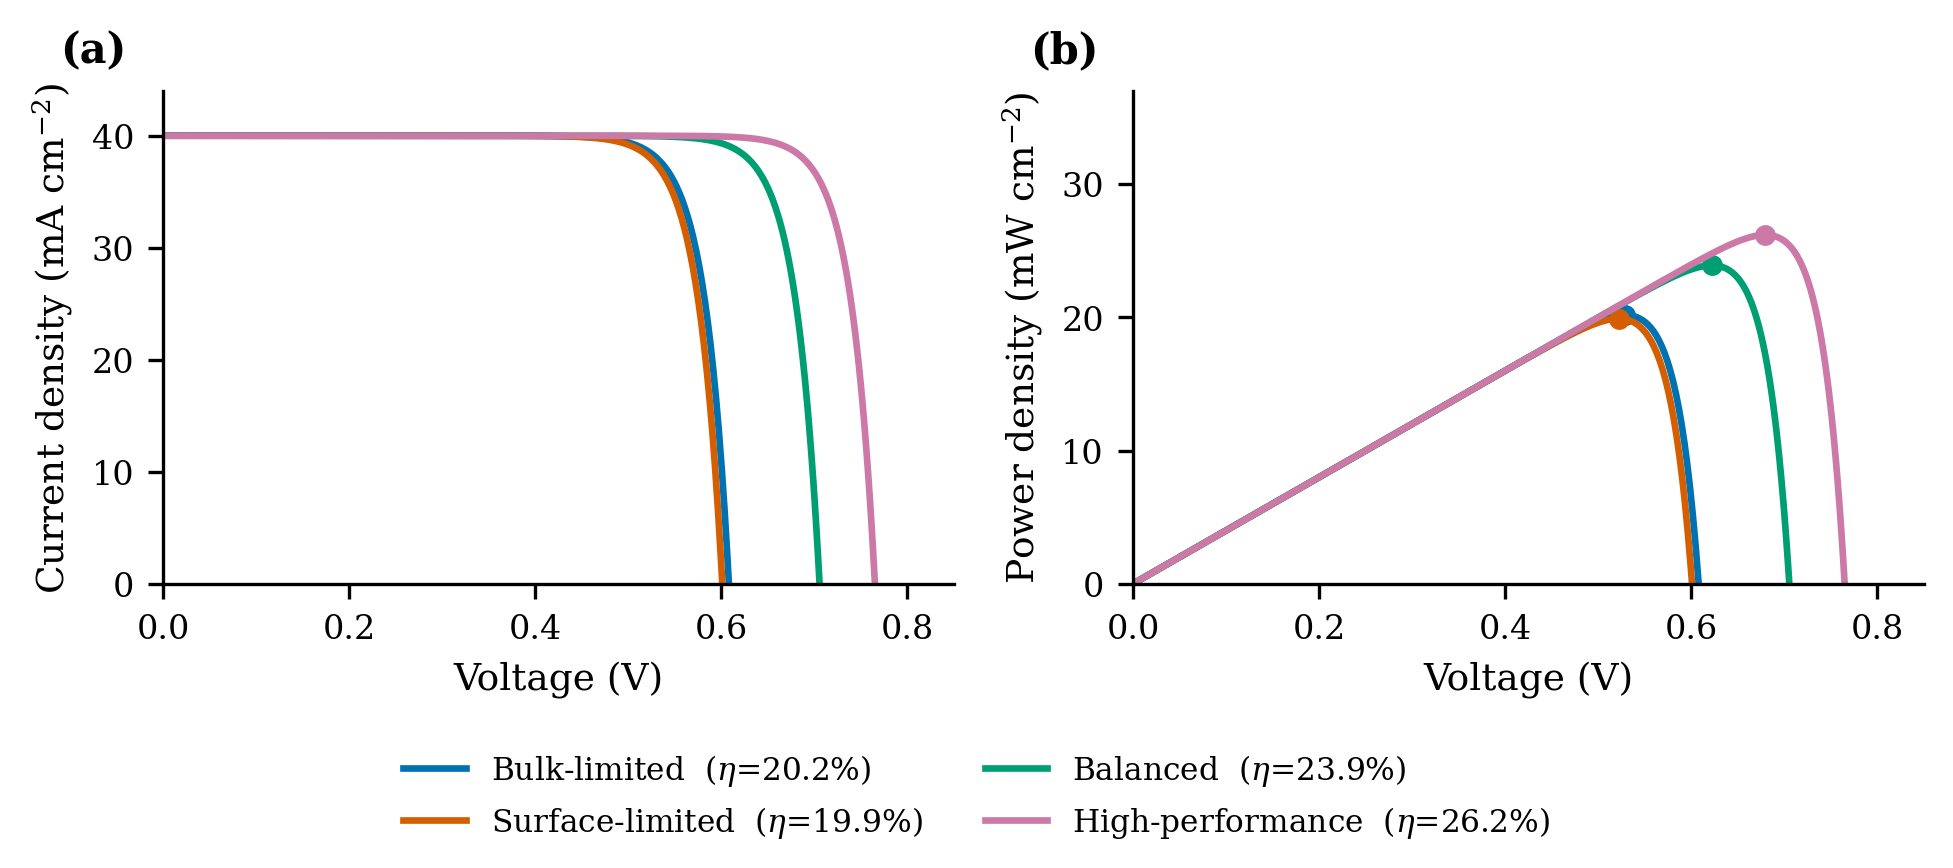

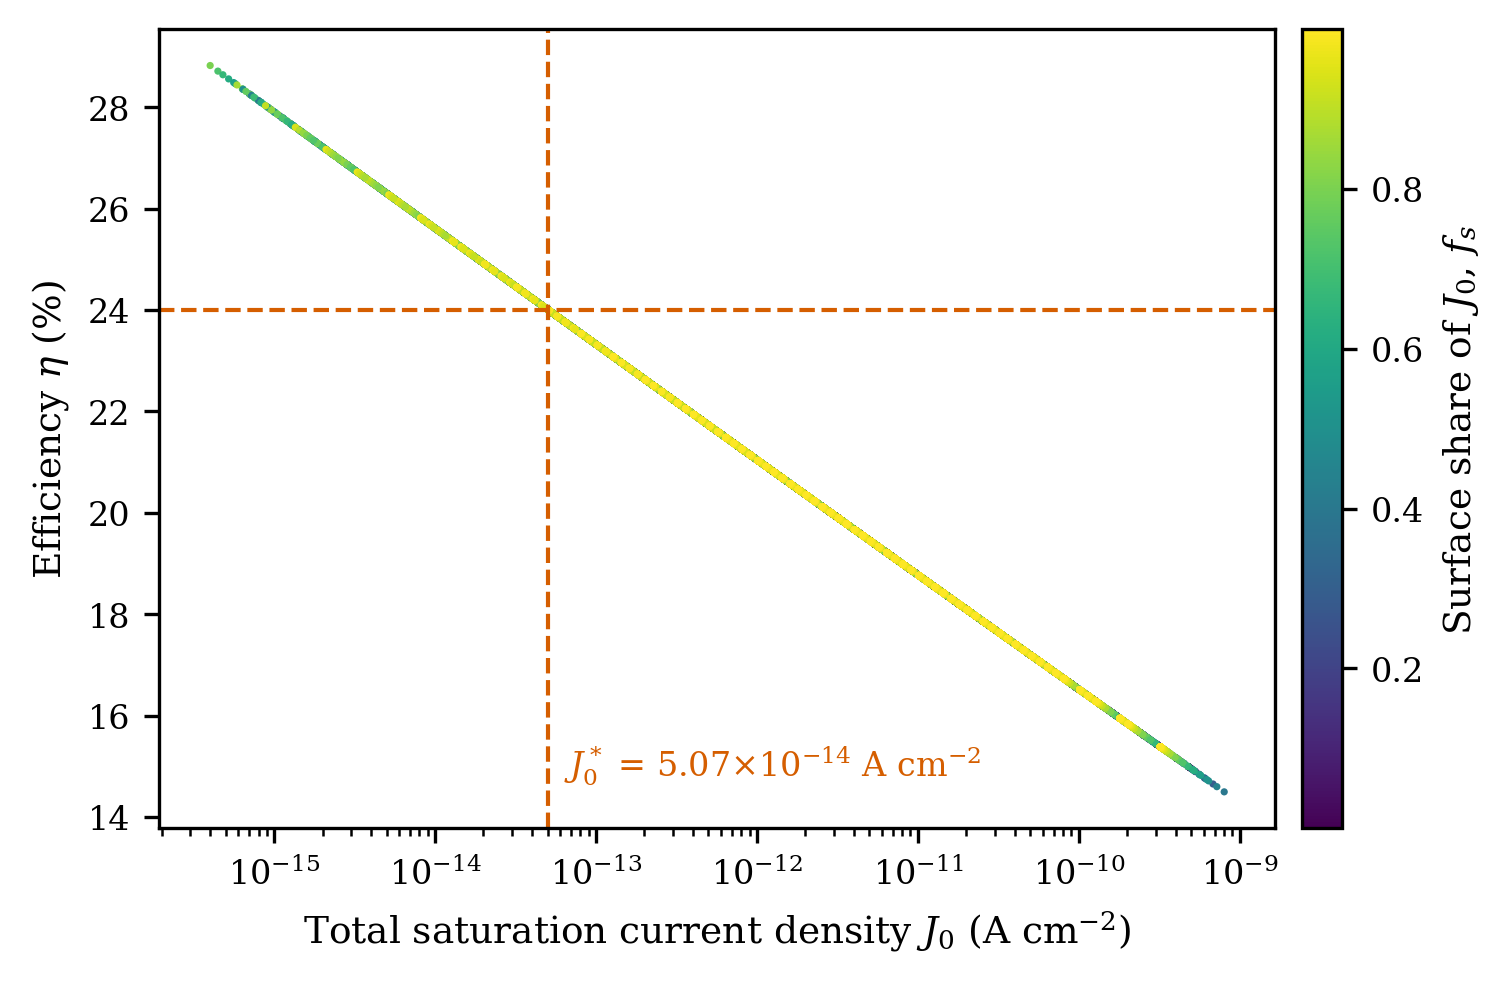

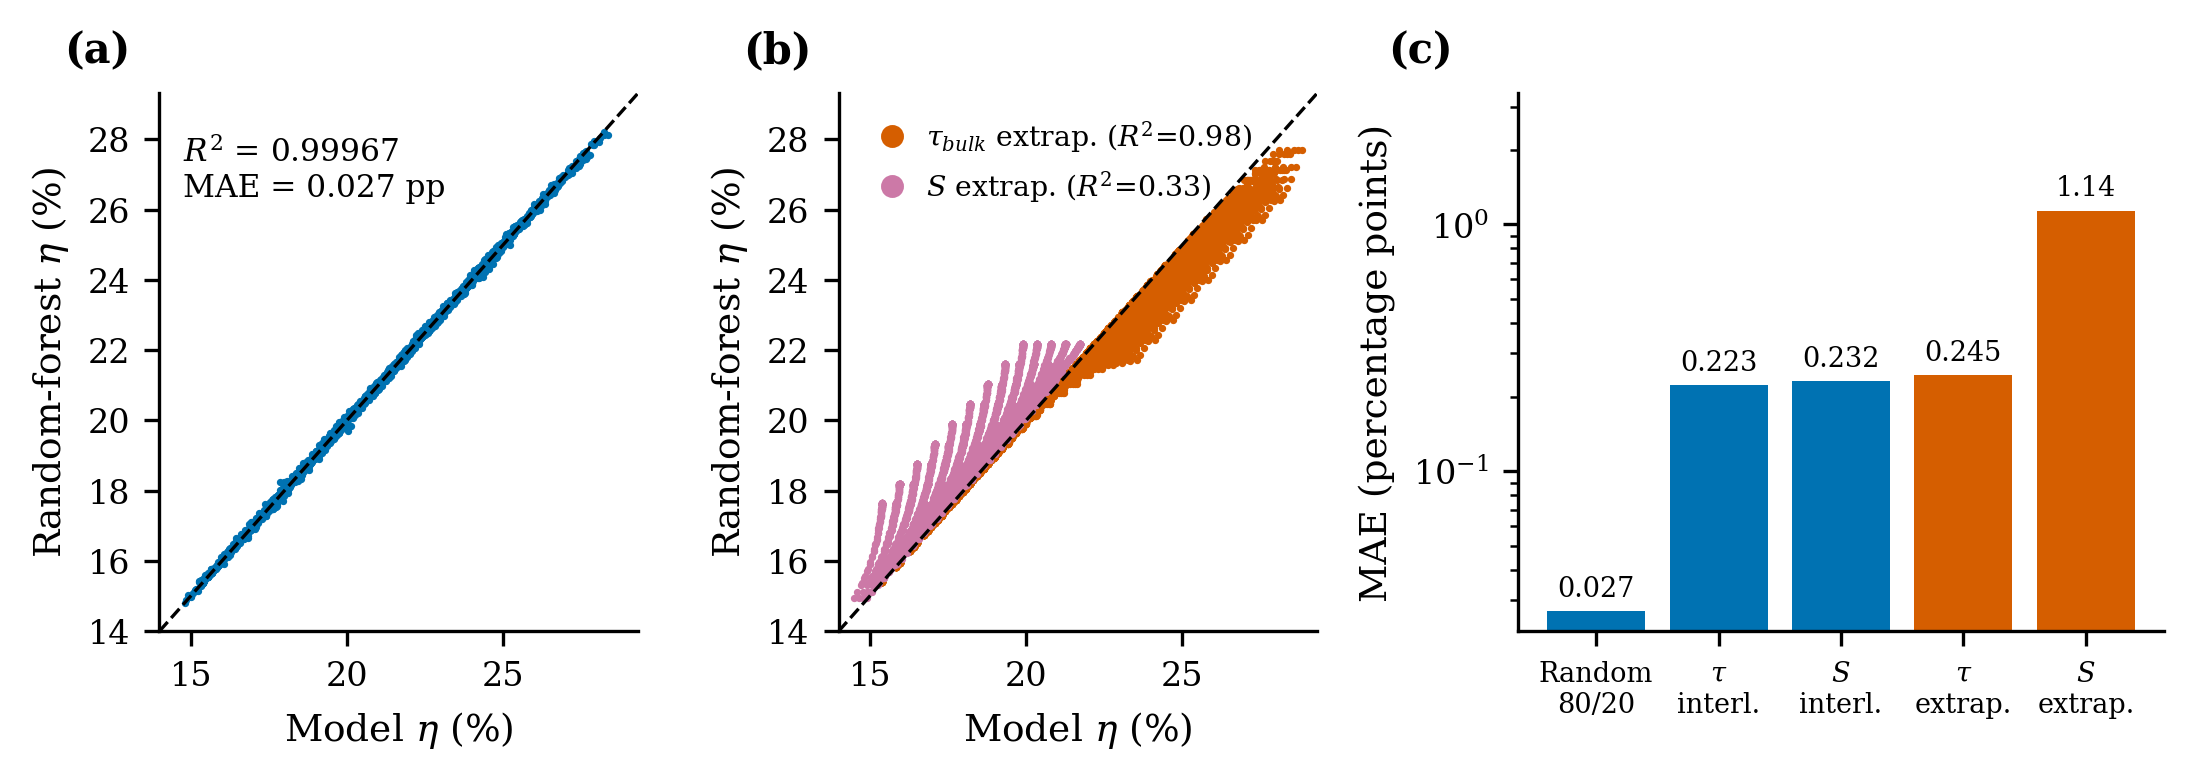

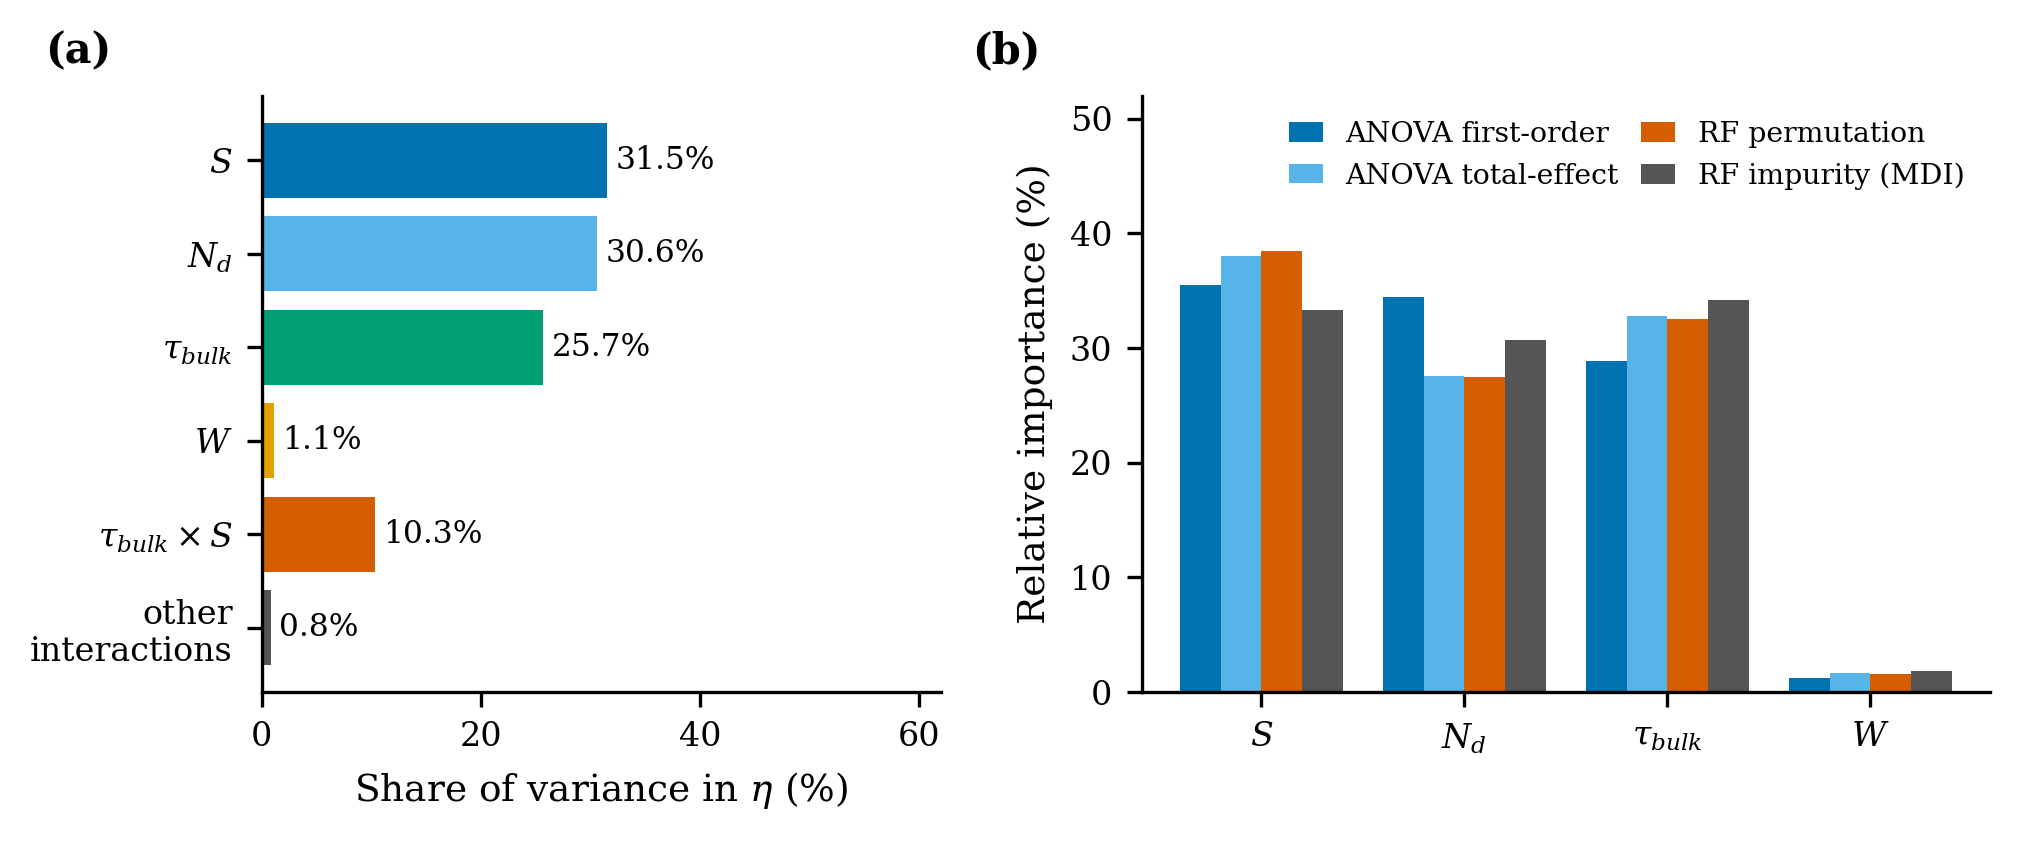

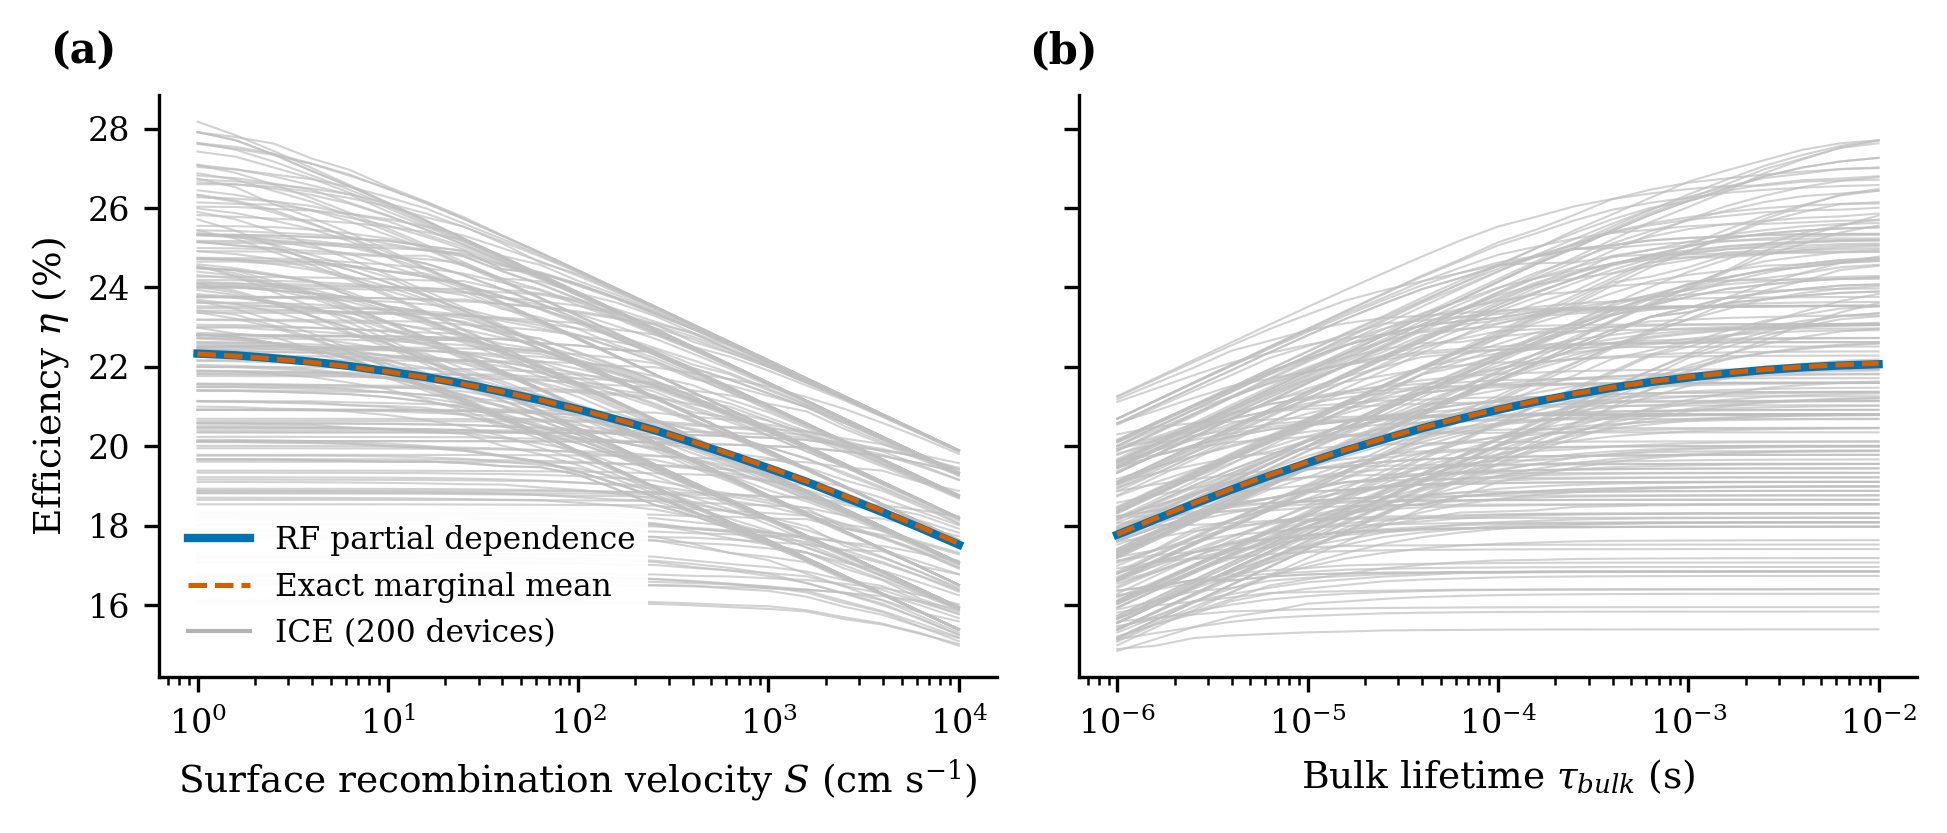

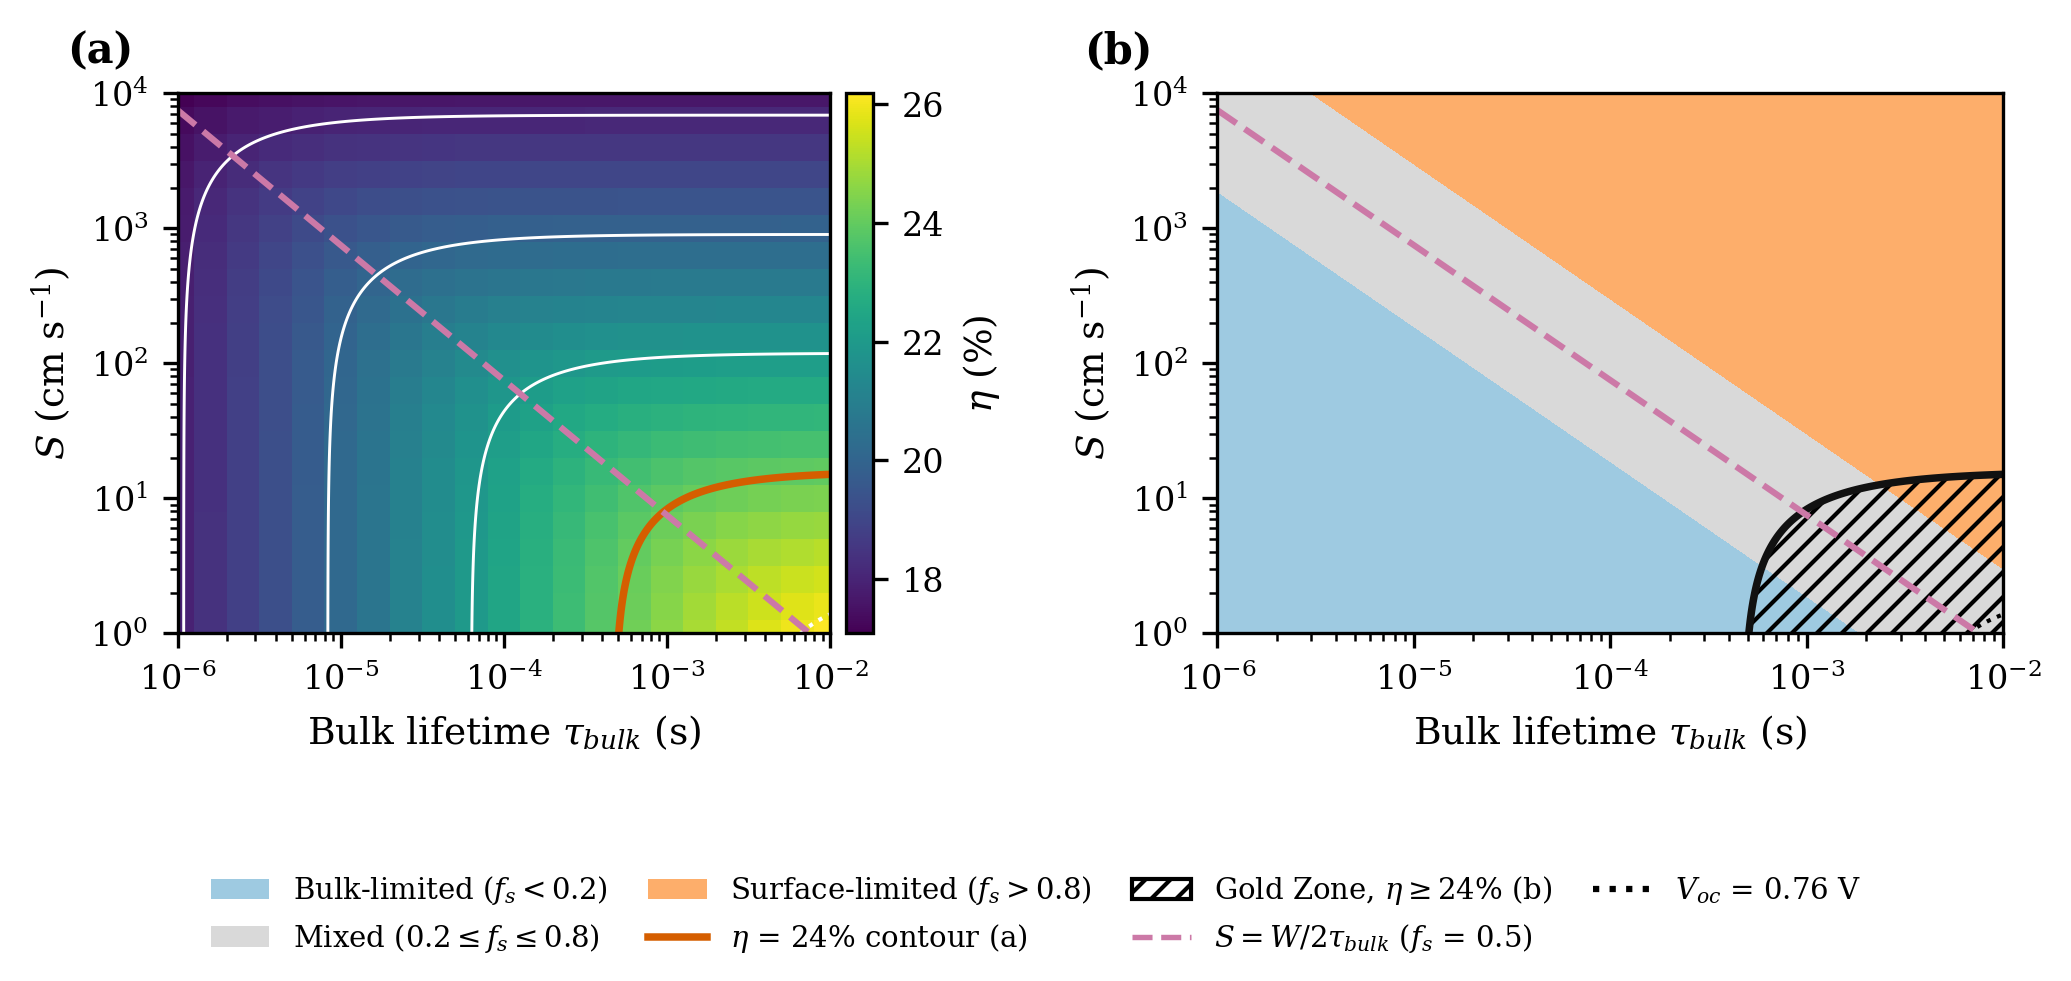

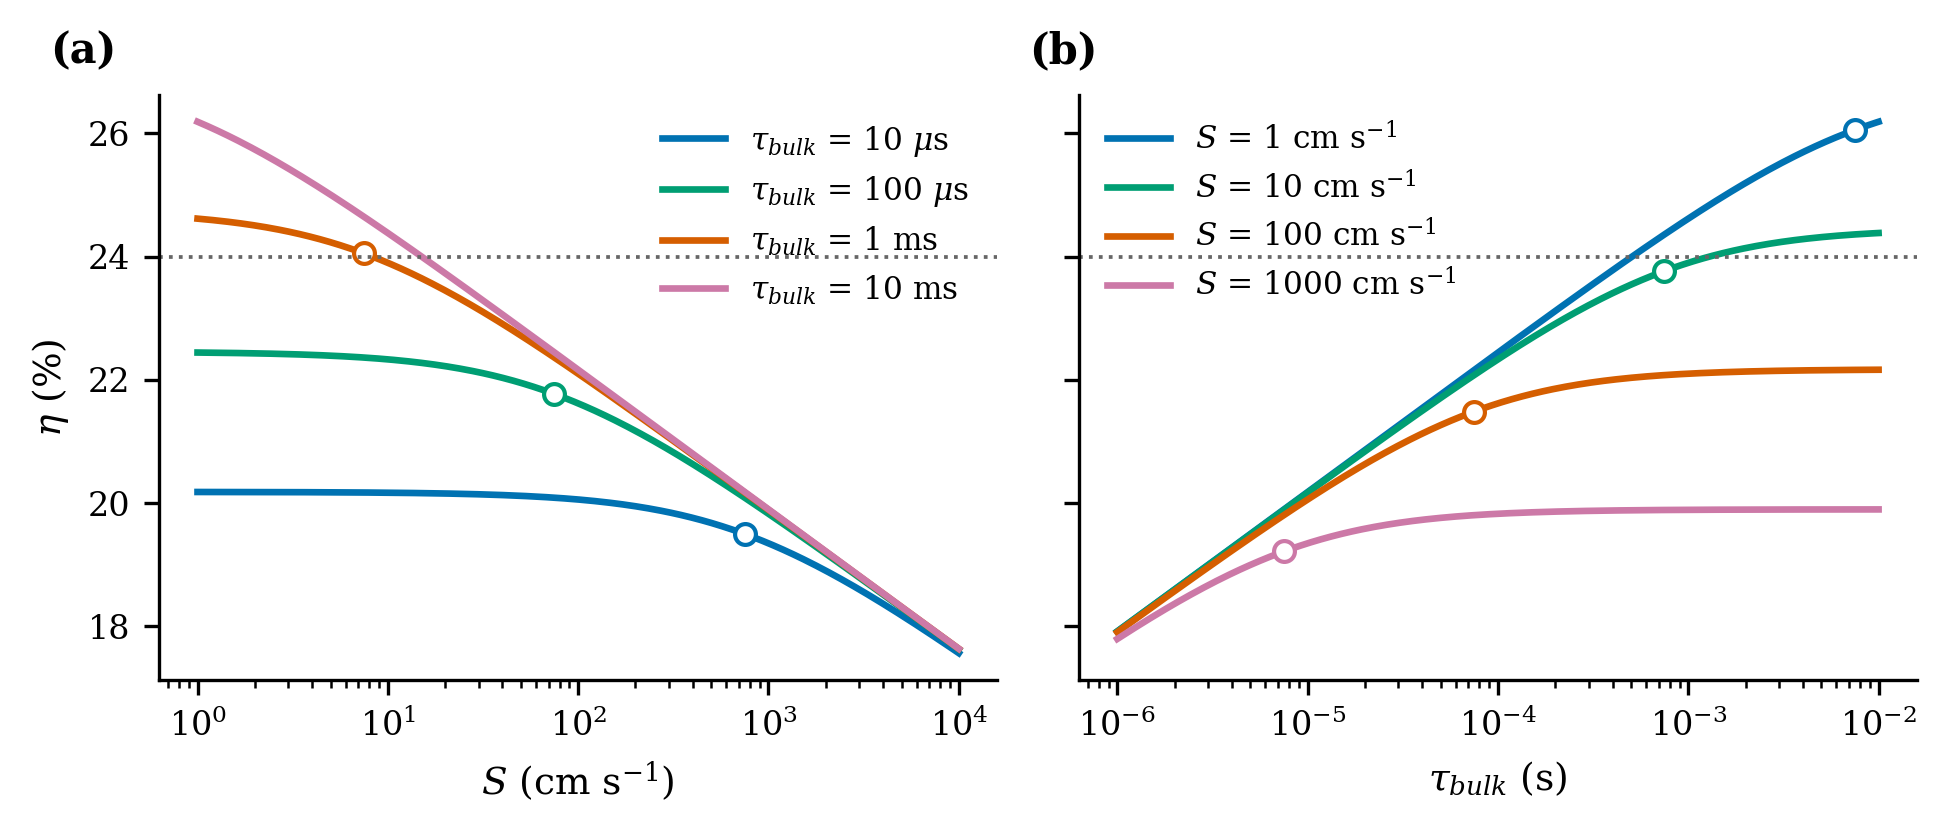

In [9]:
from IPython.display import Image, display
for n in ["fig1_jv_regimes", "fig2_collapse", "fig3_surrogate_validation", "fig4_variance_attribution", "fig5_ice_pdp", "fig6_maps", "fig7_line_cuts"]:
    display(Image(filename=f"outputs/figures/{n}.png", width=720))